In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, Stepwise, sklearn_selected

In [2]:
from sklearn.metrics import (accuracy_score, mean_squared_error)
from sklearn.ensemble import (GradientBoostingRegressor as GBR)

STATE = 161

In [3]:
Hitters = load_data('Hitters')

# (a) Remove the observations for whom the salary information is unknown, and then log-transform the salaries.
Hitters.dropna(subset=['Salary'], inplace=True)
Hitters['Salary'] = np.log(Hitters['Salary'])

# (b) Create a training set consisting of the first 200 observations, and a test set consisting of the remaining observations.
preds = Hitters.drop(columns=['Salary'])
preds = pd.get_dummies(preds, drop_first=True)
target = Hitters['Salary']

X_train, X_test, y_train, y_test = skm.train_test_split(preds, target, train_size=200, random_state=STATE)

# (c) Perform boosting on the training set with 1,000 trees for a range of values of the shrinkage parameter λ. 
#     Produce a plot with different shrinkage values on the x-axis and the corresponding training set MSE on the y-axis.
lambda_rate = [0.1, 0.05, 0.01, 0.005, 0.0001]
train_mse_list = []
test_mse_list = []

for rate in lambda_rate:
    boost_model = GBR(n_estimators=1000, learning_rate=rate, random_state=STATE)
    boost_model = boost_model.fit(X_train, y_train)
    train_pred = boost_model.predict(X_train)
    test_pred = boost_model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

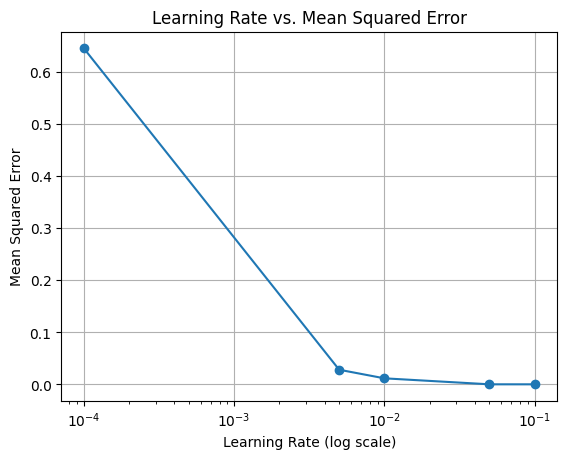

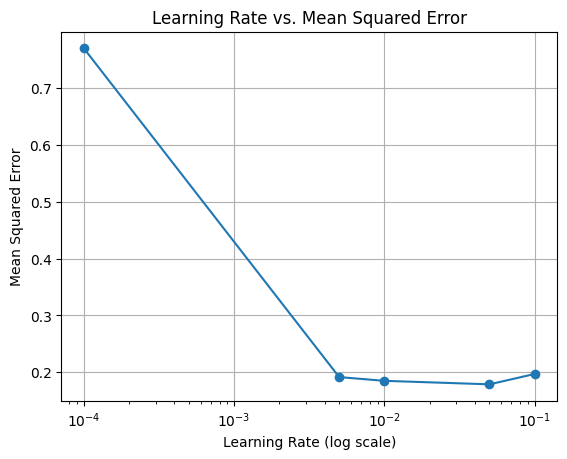

In [4]:
plt.figure()
plt.title("Shrinkage values vs Training MSE")
plt.plot(lambda_rate, train_mse_list, marker='o')
plt.xscale('log')
plt.title('Learning Rate vs. Mean Squared Error')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Mean Squared Error')
plt.grid()
plt.show()


# (d) Produce a plot with different shrinkage values on the x-axis and the corresponding test set MSE on the y-axis.
plt.figure()
plt.title("Shrinkage values vs Testing MSE")
plt.plot(lambda_rate, test_mse_list, marker='o')
plt.xscale('log')
plt.title('Learning Rate vs. Mean Squared Error')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Mean Squared Error')
plt.grid()
plt.show()

In [5]:
# (e) Compare the test MSE of boosting to the test MSE that results from applying two of the regression approaches seen
#     in Chapters 3 and 6.

# OLS from chapter 3
ols_preds = Hitters.drop(columns=['Salary'])
design = MS(ols_preds.columns).fit_transform(Hitters)

X_train, X_test, y_train, y_test = skm.train_test_split(design, target, train_size=200, random_state=STATE)

ols_model = sm.OLS(y_train, X_train).fit()
ols_prediction = ols_model.predict(X_test)

ols_mse = mean_squared_error(y_test, ols_prediction)

# Forward stepwise selection from chapter 6
strategy = Stepwise.first_peak(design, direction='forward', max_terms=len(design.terms))

hitters_MSE = sklearn_selected(OLS, strategy)
hitters_MSE.fit(Hitters, Y)

X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=200, random_state=STATE)

# Re-fit the stepwise model ONLY on the training data
stepwise_model.fit(X_train, y_train)

fs_prediction = stepwise_model.predict(X_test)
test_mse = mean_squared_error(y_test, predictions)

# (f) Which variables appear to be the most important predictors in the boosted model?

# (g) Now apply bagging to the training set. What is the test set MSE for this approach?

AttributeError: 'DataFrame' object has no attribute 'terms'